 #  GMST over Time

## Origin of Files

In [2]:
#Short history of commands and origin of files:
# The commands are for the PI dataset, the other datasets have been created exactly analogous 
# just the names of the files have been exchanged, they can be found in the folders
# /data/modeldata/ICON/icon-paleo/LIG.kepler/remapped_r2b4  &  ./data/modeldata/ICON/icon-paleo/LIG.kepler.ghg/remapped_r2b4
#
#Merging:
#        cdo mergetime ../PI.kepler.mk_atm_2d_ml_*.nc PI.kepler_atm2d_merged.nc
#
#Regridding:
#        getting gridfiles/icon_grid_0012_R02B04_G.nc
#                ==> downloaded original from ICON paleo website, is the gridfile for R02B04 grid
#        creating gridfiles/target_grid_1_5.txt
#                ==> got from Kiras 0.75 grid, changed numbers pretty self explanatory!
#
#        Creating weightfile in gridfiles:
#        cdo gendis,gridfiles/target_grid_1_5.txt -setgrid,gridfiles/icon_grid_0012_R02B04_G.nc  PI.kepler_atm2d_merged.nc gridfiles/weightfile_R02B04_to_1_5_deg
#
#        Actual Remapping:
#        cdo -remap,gridfiles/target_grid_1_5.txt,gridfiles/weightfile_R02B04_to_1_5_deg PI.kepler_atm2d_merged.nc PI.kepler_atm2d_merged_remapped.nc
#
#Selecting the relevant years:
#        cdo selyear,1770/1800 PI.kepler_atm2d_merged_remapped.nc PI.kepler_atm2d_merged_remapped_1770_1800.nc


#        Isolating Temperature and Sea Ice:
#        for whole data
#        cdo selname,t_2m,fr_seaice PI.kepler_atm2d_merged_remapped.nc PI.kepler_t2m_sif_merged_remapped.nc


# Basic Import Statements

In [3]:
# %%
import xarray as xr
import numpy as np
#from scipy.stats import pearsonr
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
#from tqdm import tqdm

# Loading rcParams

In [4]:
import importlib
import plot_settings
importlib.reload(plot_settings)

plot_settings.load_rcParams()

# Loading Data

In [5]:
PI  = xr.open_dataset('../PI.kepler/remapped_r2b4/PI.kepler_t2m_sif_merged_remapped.nc')
#LIG = xr.open_dataset('../LIG.kepler/remapped_r2b4/LIG.kepler_t2m_sif_merged_remapped.nc')
LIG_ghg = xr.open_dataset('../LIG.kepler.ghg/remapped_r2b4/LIG.kepler.ghg_t2m_sif_merged_remapped.nc')

# Usefull functions for deriving the GMST

In [6]:
def get_lat_weights(PI: xr.DataArray) -> xr.DataArray:
    """Create cosine-based latitude weights."""
    return np.cos(np.deg2rad(PI.lat))

def get_weighted_mean(PI: xr.DataArray) -> xr.DataArray:
    PI = PI.squeeze('height_2')
    weights = get_lat_weights(PI)
    PI_lat_weighted = PI.weighted(weights)
    
    return PI_lat_weighted.mean(dim=['lat', 'lon'])

def get_annual_mean(PI: xr.DataArray) -> xr.DataArray:
    """Resample to annual frequency and take the mean."""
    return PI.resample(time='YS').mean()

def get_annual_mean_from_raw_dataset(PI: xr.DataArray) -> xr.DataArray:
    PI_mean = get_weighted_mean(PI.t_2m)
    PI_annual = get_annual_mean(PI_mean)
    PI_annual = PI_annual[:-1] # cutoff last "year" as it is just the 01.01. of the new year, which has not been simulated
    return PI_annual

# Deriving the GMST

In [7]:
PI_annual = get_annual_mean_from_raw_dataset(PI)
#LIG_annual = get_annual_mean_from_raw_dataset(LIG)
LIG_ghg_annual = get_annual_mean_from_raw_dataset(LIG_ghg)

In [ ]:
# Plotting the GMST

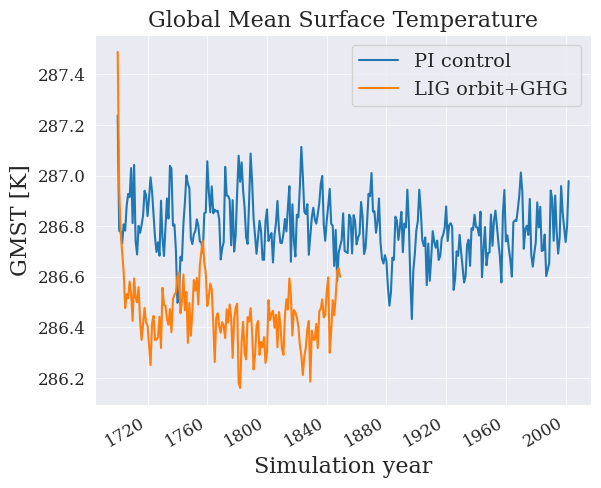

In [8]:
PI_annual.plot(label='PI control')
LIG_ghg_annual.plot(label='LIG orbit+GHG ')
ax = plt.gca()
ax.set_title('Global Mean Surface Temperature')
ax.set_ylabel('GMST [K]')
ax.set_xlabel('Simulation year')
ax.legend()
plt.savefig('figs/GMST.png')